In [4]:
from google.colab import drive
drive.mount('/content/drive')


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [5]:
import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
import glob
import cv2
import torch.nn.functional as F
from torch.autograd import Variable

import torchvision
import torchvision.transforms as transforms

from torch.nn import CrossEntropyLoss, Dropout, Softmax, Linear, Conv2d, LayerNorm
import matplotlib.pyplot as plt
from torchsummary import summary
import warnings
warnings.filterwarnings ('ignore')

In [6]:
device = 'cuda' if torch.cuda.is_available() else 'cpu'
device

'cuda'

### 1. Cài đặt BatchNorm

In [7]:
def compare_bn(bn1, bn2):
    err = False
    if not torch.allclose(bn1.running_mean, bn2.running_mean):
        print('Diff in running_mean: {} vs {}'.format(
            bn1.running_mean, bn2.running_mean))
        err = True

    if not torch.allclose(bn1.running_var, bn2.running_var):
        print('Diff in running_var: {} vs {}'.format(
            bn1.running_var, bn2.running_var))
        err = True

    if bn1.affine and bn2.affine:
        if not torch.allclose(bn1.weight, bn2.weight):
            print('Diff in weight: {} vs {}'.format(
                bn1.weight, bn2.weight))
            err = True

        if not torch.allclose(bn1.bias, bn2.bias):
            print('Diff in bias: {} vs {}'.format(
                bn1.bias, bn2.bias))
            err = True

    if not err:
        print('All parameters are equal!')


class MyBatchNorm2d(nn.BatchNorm2d):
    def __init__(self, num_features, eps = 1e-5, momentum=0.1,
                 affine = True, track_running_stats=True):
        super(MyBatchNorm2d, self).__init__(
            num_features, eps, momentum, affine, track_running_stats)

    def forward(self, input):
        self._check_input_dim(input)

        exponential_average_factor = 0.0

        if self.training and self.track_running_stats:
            if self.num_batches_tracked is not None:
                self.num_batches_tracked += 1
                if self.momentum is None:  # use cumulative moving average
                    exponential_average_factor = 1.0 / float(self.num_batches_tracked)
                else:  # use exponential moving average
                    exponential_average_factor = self.momentum

        # calculate running estimates
        if self.training:
            mean = input.mean([0, 2, 3])
            # use biased var in train
            var = input.var([0, 2, 3], unbiased=False)
            n = input.numel() / input.size(1)
            with torch.no_grad():
                self.running_mean = exponential_average_factor * mean + (1 - exponential_average_factor) * self.running_mean
                # update running_var with unbiased var
                self.running_var = exponential_average_factor * var * n / (n - 1)  + (1 - exponential_average_factor) * self.running_var
        else:
            mean = self.running_mean
            var = self.running_var

        mean_view = mean.view(1,-1,1,1)
        var_view = var.view(1,-1,1,1)
        weight_view = self.weight.view(1,-1,1,1)
        bias_view = self.bias.view(1,-1,1,1)
        input = (input - mean_view) / torch.sqrt(var_view + self.eps)
        
        if self.affine:
            input = weight_view * input + bias_view
        
        return input

# Init BatchNorm layers
my_bn = MyBatchNorm2d(3, affine=True)
bn = nn.BatchNorm2d(3, affine=True)

compare_bn(my_bn, bn)  # weight and bias should be different
# Load weight and bias
my_bn.load_state_dict(bn.state_dict())
compare_bn(my_bn, bn)

# Run train 
for _ in range(10):
    scale = torch.randint(1, 10, (1,)).float()
    bias = torch.randint(-10, 10, (1,)).float()
    x = torch.randn(10, 3, 100, 100) * scale + bias
    out1 = my_bn(x)
    out2 = bn(x)
    compare_bn(my_bn, bn)

    torch.allclose(out1, out2)
    print('Max diff: ', (out1 - out2).abs().max())

# Run eval
my_bn.eval()
bn.eval()
for _ in range(10):
    scale = torch.randint(1, 10, (1,)).float()
    bias = torch.randint(-10, 10, (1,)).float()
    x = torch.randn(10, 3, 100, 100) * scale + bias
    out1 = my_bn(x)
    out2 = bn(x)
    compare_bn(my_bn, bn)

    torch.allclose(out1, out2)

All parameters are equal!
All parameters are equal!
All parameters are equal!
Max diff:  tensor(4.7684e-07, grad_fn=<MaxBackward1>)
All parameters are equal!
Max diff:  tensor(4.7684e-07, grad_fn=<MaxBackward1>)
All parameters are equal!
Max diff:  tensor(9.5367e-07, grad_fn=<MaxBackward1>)
All parameters are equal!
Max diff:  tensor(4.7684e-07, grad_fn=<MaxBackward1>)
All parameters are equal!
Max diff:  tensor(4.7684e-07, grad_fn=<MaxBackward1>)
All parameters are equal!
Max diff:  tensor(4.7684e-07, grad_fn=<MaxBackward1>)
All parameters are equal!
Max diff:  tensor(9.5367e-07, grad_fn=<MaxBackward1>)
All parameters are equal!
Max diff:  tensor(9.5367e-07, grad_fn=<MaxBackward1>)
All parameters are equal!
Max diff:  tensor(9.5367e-07, grad_fn=<MaxBackward1>)
All parameters are equal!
Max diff:  tensor(4.7684e-07, grad_fn=<MaxBackward1>)
All parameters are equal!
All parameters are equal!
All parameters are equal!
All parameters are equal!
All parameters are equal!
All parameters are

### 2. Cài đặt chiến lược thay đổi tốc độ học: Warm-up + Cosine Annealing LR

In [8]:
def load_data(data_dir="./data"):
    transform = transforms.Compose([
        transforms.ToTensor(),                            
        transforms.Normalize(mean =  (0.5, 0.5, 0.5),std = (0.5, 0.5, 0.5)),
    ])

    trainset = torchvision.datasets.CIFAR10(
        root=data_dir, train=True, download=True, transform=transform)

    testset = torchvision.datasets.CIFAR10(
        root=data_dir, train=False, download=True, transform=transform)

    return trainset, testset

class Net(nn.Module):
    def __init__(self, l1=120, l2=84):
        super(Net, self).__init__()
        self.conv1 = nn.Conv2d(3, 6, 5)
        self.pool = nn.MaxPool2d(2, 2)
        self.conv2 = nn.Conv2d(6, 16, 5)
        self.fc1 = nn.Linear(16 * 5 * 5, l1)
        self.fc2 = nn.Linear(l1, l2)
        self.fc3 = nn.Linear(l2, 10)
        self.softmax = nn.Softmax()

    def forward(self, x):
        x = self.pool(F.relu(self.conv1(x)))
        x = self.pool(F.relu(self.conv2(x)))
        x = x.view(-1, 16 * 5 * 5)
        x = F.relu(self.fc1(x))
        x = F.relu(self.fc2(x))
        x = self.fc3(x)
        x = self.softmax(x)

        return x

In [9]:
trainset, testset = load_data('./data')
trainloader = torch.utils.data.DataLoader(
    trainset,
    batch_size=128,
    shuffle=True,
)

epochs = 50
warm_epoch = 5
init_lr = 1e-1
last_lr = 1e-5
T_max = epochs
T_cur = 0
lr_list = [0]

net = Net()
net.to(device)

criterion = nn.CrossEntropyLoss()
optimizer = optim.SGD(net.parameters(), lr=init_lr, momentum=0.9)

In [10]:
from math import pi
from math import cos

for epoch in range(1, epochs + 1):  # loop over the dataset multiple times
    running_loss = 0.0
    epoch_steps = 0
    T_cur += 1
    optimizer.param_groups[0]['lr'] = 0.5 * init_lr * (1 + cos(epoch * pi / epochs))
   
    for i, data in enumerate(trainloader, 0):
        # get the inputs; data is a list of [inputs, labels]
        inputs, labels = data
        inputs, labels = inputs.to(device), labels.to(device)

        # zero the parameter gradients
        optimizer.zero_grad()

        # forward + backward + optimize
        outputs = net(inputs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        # print statistics
        running_loss += loss.item()
        epoch_steps += 1
        if i + 1 == len(trainloader):
            print("[Epoch %d] loss: %.3f" % (epoch, running_loss / epoch_steps))
            running_loss = 0.0
            
    lr_list.append(optimizer.param_groups[0]['lr'])

print("Finished Training")

[Epoch 1] loss: 2.223
[Epoch 2] loss: 2.100
[Epoch 3] loss: 2.149
[Epoch 4] loss: 2.309
[Epoch 5] loss: 2.333
[Epoch 6] loss: 2.326
[Epoch 7] loss: 2.319
[Epoch 8] loss: 2.301
[Epoch 9] loss: 2.315
[Epoch 10] loss: 2.332
[Epoch 11] loss: 2.361
[Epoch 12] loss: 2.359
[Epoch 13] loss: 2.357
[Epoch 14] loss: 2.329
[Epoch 15] loss: 2.333
[Epoch 16] loss: 2.350
[Epoch 17] loss: 2.349
[Epoch 18] loss: 2.361
[Epoch 19] loss: 2.361
[Epoch 20] loss: 2.361
[Epoch 21] loss: 2.361
[Epoch 22] loss: 2.361
[Epoch 23] loss: 2.361
[Epoch 24] loss: 2.361
[Epoch 25] loss: 2.361
[Epoch 26] loss: 2.361
[Epoch 27] loss: 2.361
[Epoch 28] loss: 2.361
[Epoch 29] loss: 2.361
[Epoch 30] loss: 2.361
[Epoch 31] loss: 2.361
[Epoch 32] loss: 2.361
[Epoch 33] loss: 2.361
[Epoch 34] loss: 2.361
[Epoch 35] loss: 2.361
[Epoch 36] loss: 2.361
[Epoch 37] loss: 2.361
[Epoch 38] loss: 2.361
[Epoch 39] loss: 2.361
[Epoch 40] loss: 2.361
[Epoch 41] loss: 2.361
[Epoch 42] loss: 2.361
[Epoch 43] loss: 2.361
[Epoch 44] loss: 2.3

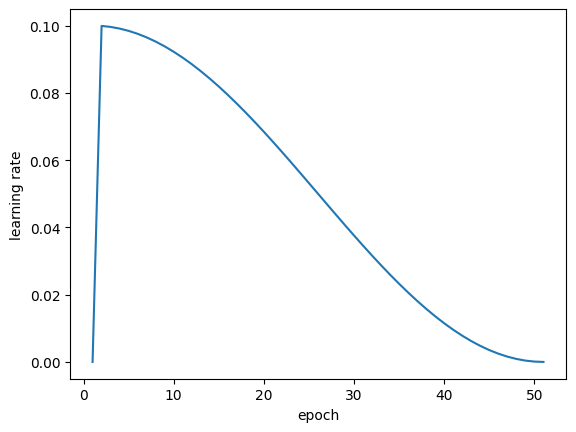

In [12]:
plt.figure()
plt.plot([i for i in range(1,52)], lr_list)
plt.xlabel('epoch')
plt.ylabel('learning rate')
plt.show()

### 3. Tuning siêu tham số

In [13]:
!pip install ray


In [14]:
import os
from ray.tune import CLIReporter
from ray import tune
from torch.utils.data import random_split
from functools import partial

In [15]:
def train_cifar(config, checkpoint_dir=None, data_dir=None):
    net = Net(config["l1"], config["l2"])
    net.to(device)

    criterion = nn.CrossEntropyLoss()
    optimizer = optim.SGD(net.parameters(), lr=config["lr"], momentum = 0.9)

    if checkpoint_dir:
        model_state, optimizer_state = torch.load(
            os.path.join(checkpoint_dir, "checkpoint"))
        net.load_state_dict(model_state)
        optimizer.load_state_dict(optimizer_state)

    trainset, testset = load_data(data_dir)

    test_abs = int(len(trainset) * 0.8)
    train_subset, val_subset = random_split(
        trainset, [test_abs, len(trainset) - test_abs])

    trainloader = torch.utils.data.DataLoader(
        train_subset,
        batch_size=int(config["batch_size"]),
        shuffle=True,
        num_workers=8)
    valloader = torch.utils.data.DataLoader(
        val_subset,
        batch_size=int(config["batch_size"]),
        shuffle=True,
        num_workers=8)

    for epoch in range(5):  # loop over the dataset multiple times
        running_loss = 0.0
        epoch_steps = 0
        for i, data in enumerate(trainloader, 0):
            # get the inputs; data is a list of [inputs, labels]
            inputs, labels = data
            inputs, labels = inputs.to(device), labels.to(device)

            # zero the parameter gradients
            optimizer.zero_grad()

            # forward + backward + optimize
            outputs = net(inputs)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()

            # print statistics
            running_loss += loss.item()
            epoch_steps += 1
            if i % 2000 == 1999:  # print every 2000 mini-batches
                print("[%d, %5d] loss: %.3f" % (epoch + 1, i + 1,
                                                running_loss / epoch_steps))
                running_loss = 0.0

        # Validation loss
        val_loss = 0.0
        val_steps = 0
        total = 0
        correct = 0
        for i, data in enumerate(valloader, 0):
            with torch.no_grad():
                inputs, labels = data
                inputs, labels = inputs.to(device), labels.to(device)

                outputs = net(inputs)
                _, predicted = torch.max(outputs.data, 1)
                total += labels.size(0)
                correct += (predicted == labels).sum().item()

                loss = criterion(outputs, labels)
                val_loss += loss.cpu().numpy()
                val_steps += 1

        with tune.checkpoint_dir(epoch) as checkpoint_dir:
            path = os.path.join(checkpoint_dir, "checkpoint")
            torch.save((net.state_dict(), optimizer.state_dict()), path)
            print("*"*10, path, "*"*10)

        tune.report(loss=(val_loss / val_steps), accuracy=correct / total)
    print("Finished Training")

In [17]:
!pip install skorch
import numpy as np
from sklearn.datasets import make_classification
from torch import nn

from skorch import NeuralNetClassifier
from sklearn.model_selection import GridSearchCV

In [18]:
trainset, testset = load_data('./data')
(X, y) = np.asarray(trainset.data[:]), np.asarray(trainset.targets[:])
X = X.reshape((-1, 3, 32, 32))
X = X.astype(np.float32)
y = y.astype(np.int64)

net = NeuralNetClassifier(
    Net,
    max_epochs=5,
    lr=0.01,
    # Shuffle training data on each epoch
    iterator_train__shuffle=True,
)

# training with default config
net.fit(X, y)
y_proba = net.predict_proba(X)

  epoch    train_loss    valid_acc    valid_loss     dur
-------  ------------  -----------  ------------  ------
      1        2.2244       0.2078        2.1582  7.9833
      2        2.0922       0.2602        2.0807  8.6566
      3        2.0172       0.2792        1.9740  8.9345
      4        1.9522       0.2683        2.0090  7.6930
      5        1.9029       0.2586        2.0264  8.9265


In [19]:
# hyperparameter tuning
net.set_params(train_split=False, verbose=0)
# Liệt kê các giá trị siêu tham số cần search và dùng hàm gridsearchCV để tìm giá trị tối ưu
param_grid = {
    'lr': [1e-4, 1e-2],
    'module__l1': [32, 64],
    'module__l2': [16, 32],
}
gs = GridSearchCV(estimator = net, param_grid = param_grid,cv = 3,scoring = 'accuracy', verbose = 2)
gs.fit(X, y)
print("best score: {:.3f}, best params: {}".format(gs.best_score_, gs.best_params_))

Fitting 3 folds for each of 8 candidates, totalling 24 fits
[CV] END ............lr=0.0001, module__l1=32, module__l2=16; total time=  32.1s
[CV] END ............lr=0.0001, module__l1=32, module__l2=16; total time=  33.3s
[CV] END ............lr=0.0001, module__l1=32, module__l2=16; total time=  32.2s
[CV] END ............lr=0.0001, module__l1=32, module__l2=32; total time=  32.4s
[CV] END ............lr=0.0001, module__l1=32, module__l2=32; total time=  33.1s
[CV] END ............lr=0.0001, module__l1=32, module__l2=32; total time=  32.4s
[CV] END ............lr=0.0001, module__l1=64, module__l2=16; total time=  34.6s
[CV] END ............lr=0.0001, module__l1=64, module__l2=16; total time=  33.7s
[CV] END ............lr=0.0001, module__l1=64, module__l2=16; total time=  33.6s
[CV] END ............lr=0.0001, module__l1=64, module__l2=32; total time=  34.7s
[CV] END ............lr=0.0001, module__l1=64, module__l2=32; total time=  33.4s
[CV] END ............lr=0.0001, module__l1=64, mo